# Load

In [50]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4
from qick_workspace.scrip.base_experiment import BaseExperiment
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

file_path = r'D:\Labber_Data\Jay\twpa'
BaseExperiment.setup(soc, soccfg, file_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a26a06964c834b27b9923f561f181a5d@192.168.10.82:41297
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=

# qb setting

In [51]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# onetone check

c:\Users\cluster\Desktop\SQC_soc-main\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


abcd_rf_fit result:
 {'Fres(GHz)': np.float64(6.9533), 'Qi': 7, 'absQc': -3, 'Ql': -4, 'κ(MHz)': np.float64(-1602.12)}


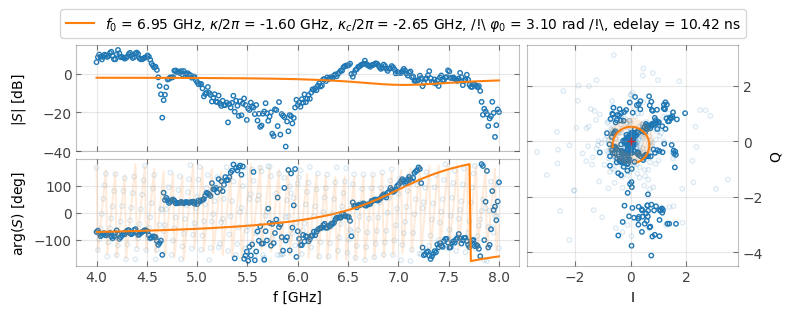

In [53]:
from qick_workspace.scrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
START_FREQ = 4000 # [MHz]
STOP_FREQ = 8000  # [MHz]


STEPS = 301

config_all.update("res.res_gain_ge", 0.02, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
result = onetone.run(py_avg=1, solve_type="hm")
# ## update value ##
# config_all.update("res_freq_ge", round(result['Fres(GHz)']*1e3, 4), q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

# connect yoko

In [68]:
from qick_workspace.tools.YOKOGS200 import YOKOGS200
import pyvisa

rm = pyvisa.ResourceManager()
yoko_connect = "USB0::0x0B21::0x0039::91S522309::INSTR"
yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
yoko.OutputOff()

In [67]:
yoko.SetMode("current")
yoko.current_ramp_step = 10e-6
yoko.ramp_interval = 0.01
# yokocurrent = 0.640 * 1e-3
yokocurrent = 0 * 1e-3

yoko.SetCurrent(yokocurrent)
yoko.GetValue()

Setting Current:   0%|          | 0/64 [00:00<?, ?it/s]

{'unit': 'A', 'value': 0.0}

# currwnt range

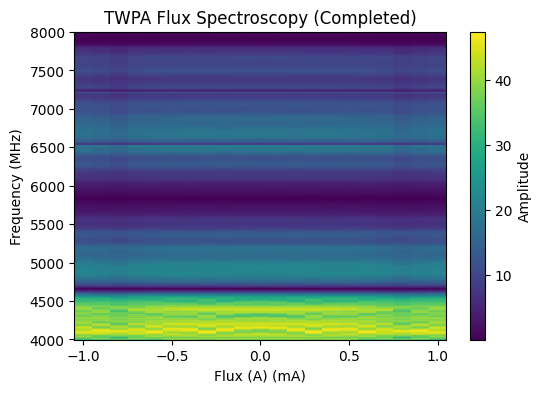

Data saved to D:\Labber_Data\Jay\twpa\2026\04\Data_0421\TWPA_flux_Q1_047


In [35]:
from qick_workspace.scrip.s002d_TWPA_flux import TWPAFlux


START_FREQ = 4000  # [MHz]
STOP_FREQ = 8000  # [MHz]
STEPS = 601

Start_flux = 1
Stop_flux = -1
Steps_flux = 21
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux) * 1e-3

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("res_gain_ge", 1),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
        ("yoko_range", yoko_range),
    ]
)

twpa = TWPAFlux(run_cfg)
###
twpa.YOKO_CURRENT_RAMP_STEP = 10e-6
twpa.YOKO_RAMP_INTERVAL = 0.01
###
twpa.run(
    3, yoko_inst=yoko_connect, yoko_value=yoko_range, yoko_mode="current"
)
twpa.saveLabber(qubit, config_all=config_all)

Peak-to-peak electrical length = 1.599 ns


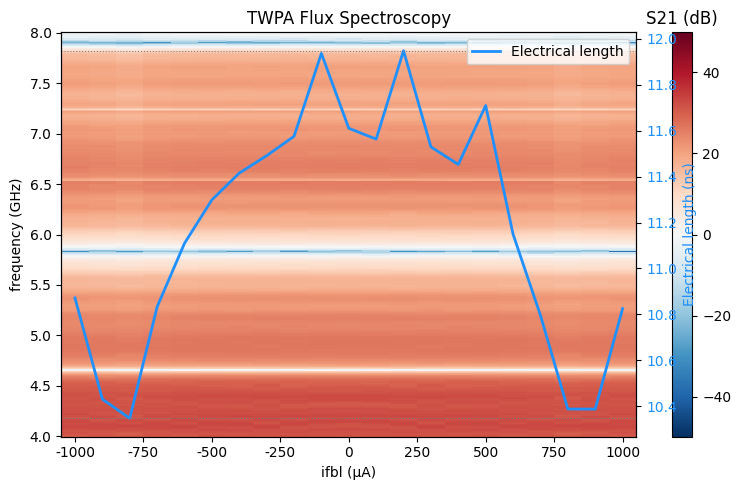

In [34]:
fig = twpa.plot()

In [5]:
from qick_workspace.scrip.s002e_TWPA_gain import TWPAGain
from qick_workspace.tools.mg3692 import AnritsuMG3692


pump = AnritsuMG3692("192.168.10.182")

Connected to: ANRITSU,MG3692C,192403,3.62


In [65]:
pump.frequency = 1.145e+10
pump.output(True)
pump.power=21

In [66]:
pump.off()

# pump frequency

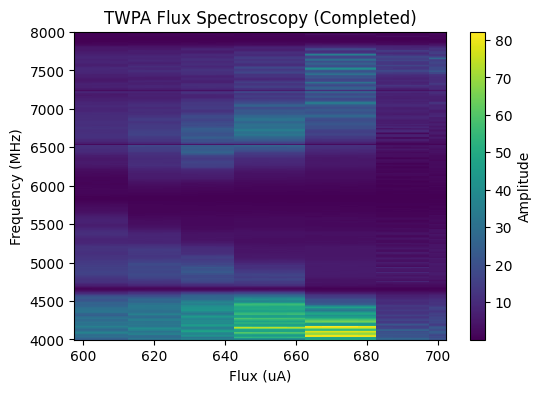

Data saved to D:\Labber_Data\Jay\twpa\2026\04\Data_0421\TWPA_flux_TWPA_pumpfreq_11.50GHz_power_+25.0dBm_002
Gain data saved to temp\2026\04\Data_0421\temp_gain.nc
Reference saved to temp\2026\04\Data_0421\temp_gain_reference.nc
[saved] 21/21 pump_freq steps → temp


In [ ]:
from qick_workspace.scrip.s002e_TWPA_gain import TWPAGain
from qick_workspace.tools.mg3692 import AnritsuMG3692
from qick_workspace.scrip.s002d_TWPA_flux import TWPAFlux



START_FREQ = 4000  # [MHz]
STOP_FREQ = 8000  # [MHz]
STEPS = 501


Start_flux = 0.5
Stop_flux = 0.7
Steps_flux = 21
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux) * 1e-3

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("res_gain_ge", 0.4),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
        ("yoko_range", yoko_range),
    ]
)
# Step 1：量 unpumped reference（pump OFF）
ref = TWPAFlux(run_cfg)

ref.YOKO_CURRENT_RAMP_STEP = 10e-6
ref.YOKO_RAMP_INTERVAL = 0.01
pump.output(False)
print('Pump status: ', pump.output())
ref.run(1, yoko_inst=yoko_connect, yoko_value=yoko_range, yoko_mode="current")
ref.saveLabber(qubit, config_all=config_all, name="unpumped_ref")


PUMP_FREQS = np.linspace(10e9, 11e9, 21)
pump.output(True)
gain = TWPAGain(run_cfg, pump, pump_freqs=PUMP_FREQS, pump_power=25)
gain.YOKO_CURRENT_RAMP_STEP = 10e-6
gain.YOKO_RAMP_INTERVAL = 0.01

gain.run(1, yoko_inst=yoko_connect, yoko_value=yoko_range,
         temp_folder="temp",
         save_raw=True,
         reference=ref)


In [33]:
best[-3]

<xarray.DataArray 'total_score' ()> Size: 8B
array(30.05636726)
Coordinates:
    ifbl       float64 8B 0.000645
    pump_freq  float64 8B 1.14e+10

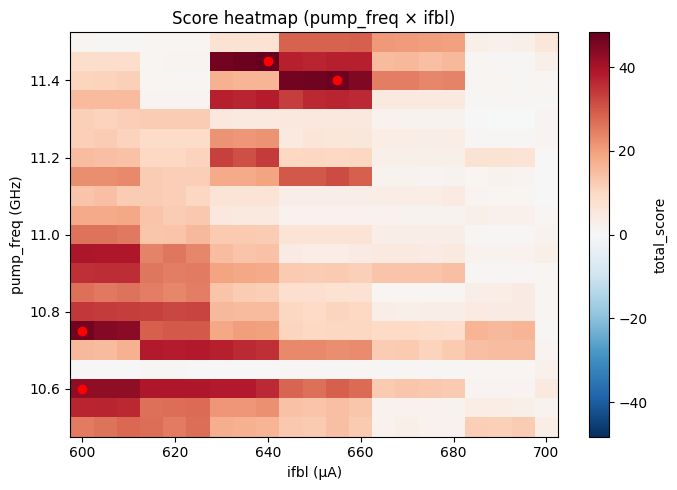

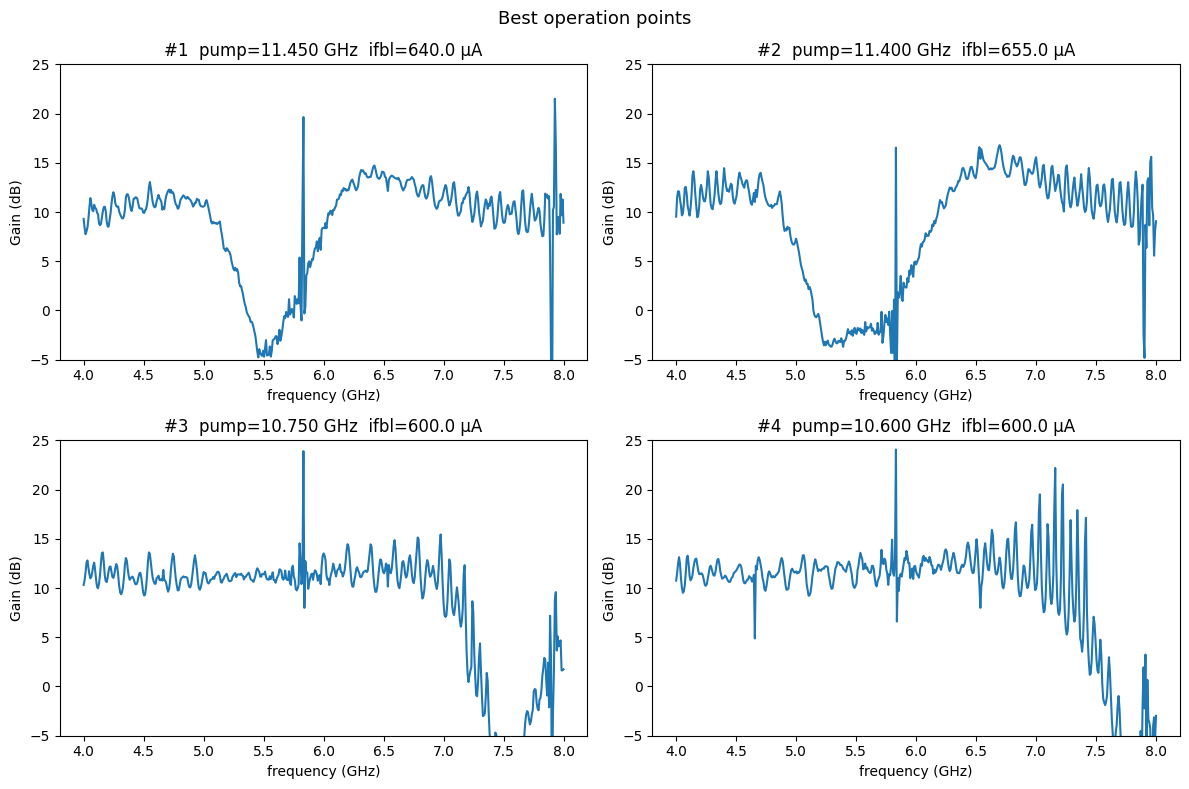


=== Best operation points ===
  #1  pump_freq = 11.4500 GHz  |  ifbl = 640.00 µA  |  score = 48.283
  #2  pump_freq = 11.4000 GHz  |  ifbl = 655.00 µA  |  score = 47.224
  #3  pump_freq = 10.7500 GHz  |  ifbl = 600.00 µA  |  score = 46.604
  #4  pump_freq = 10.6000 GHz  |  ifbl = 600.00 µA  |  score = 42.911


In [45]:
best, score = gain.analyze(
    reference=ref,
    gain_min=10,  # [dB]
    n_best=4
)

Setting Current:   0%|          | 0/1 [00:00<?, ?it/s]

Pump ON  | freq = 11.4500 GHz | flux = 0.6400 mA


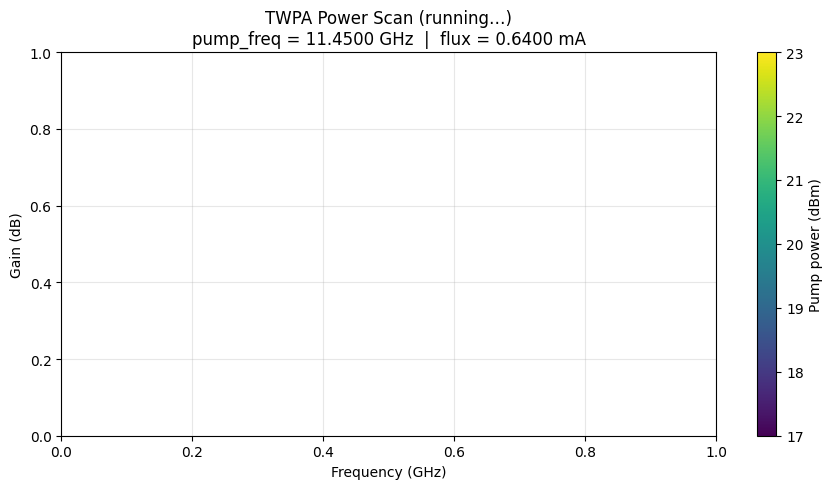

pump_power sweep:   0%|          | 0/7 [00:00<?, ?it/s]

  pump_power = +17.0 dBm


Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_33448\3396554320.py", line 13, in <module>
    scan.run(1, yoko_inst=yoko_connect, reference=ref)
  File "c:\Users\cluster\Desktop\SQC_soc-main\qick_workspace\scrip\s002g_TWPA_power_scan.py", line 231, in run
    _y = 20 * np.log10(np.abs(_sl.values / _ref_row.values))
ValueError: operands could not be broadcast together with shapes (301,) (501,) 


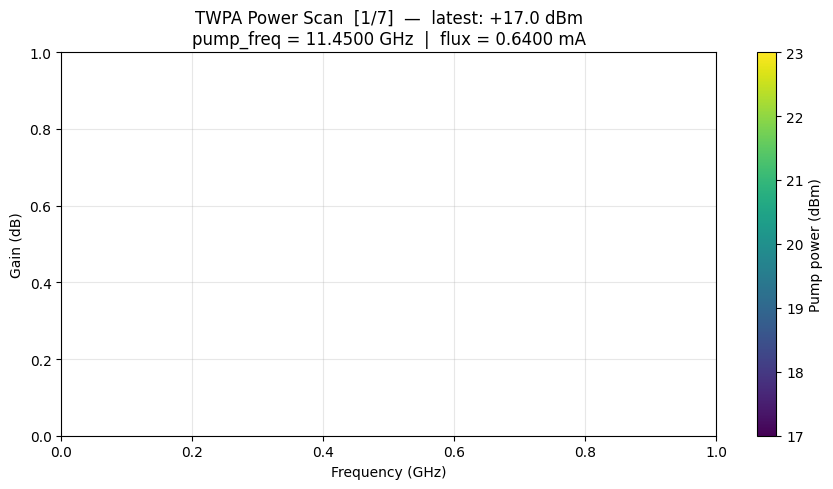

In [ ]:
from qick_workspace.scrip.s002g_TWPA_power_scan import TWPAPowerScan
from qick_workspace.scrip.s002e_TWPA_gain import TWPAGain
from qick_workspace.tools.mg3692 import AnritsuMG3692
from qick_workspace.scrip.s002d_TWPA_flux import TWPAFlux



START_FREQ = 4000  # [MHz]
STOP_FREQ = 8000  # [MHz]
STEPS = 501
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("res_gain_ge", 0.4),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
    ]
)
PUMP_FREQ  = 11.45e9          # Hz — fixed
FLUX_VALUE = 0.64e-3         # A  — fixed (pick one from yoko_range)
PUMP_POWERS = np.arange(17, 24, 1)   # dBm, adjust range as needed

scan = TWPAPowerScan(run_cfg, pump, pump_freq=PUMP_FREQ,
                     pump_powers=PUMP_POWERS, flux_value=FLUX_VALUE)
scan.YOKO_CURRENT_RAMP_STEP = 10e-6
scan.YOKO_RAMP_INTERVAL = 0.01

pump.output(True)
scan.run(1, yoko_inst=yoko_connect, reference=ref)  

scan.analyze(reference=ref, f_min=6e9, f_max=8e9)